# 02 - Model Training + Pipeline Debug (FD001)

**Purpose:** Train a simple LSTM model and verify it learns non-constant RUL patterns.

**Inputs:** `data/processed/X_train_sequences.npy`, `data/processed/y_train_sequences.npy`, `data/processed/train_sequence_unit_ids.npy`

**Outputs:** `model/best_model.pth`, `model/training_loss_curve.png`, `model/predicted_vs_actual_rul.png`

In [12]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from model.lstm_model import LSTMRULModel

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")
RUL_CAP = 125.0
torch.manual_seed(42)
np.random.seed(42)

In [13]:
X_all = np.load(PROCESSED_DIR / "X_train_sequences.npy")
y_all = np.load(PROCESSED_DIR / "y_train_sequences.npy")
seq_unit_ids = np.load(PROCESSED_DIR / "train_sequence_unit_ids.npy")

unique_units = np.unique(seq_unit_ids)
train_units, val_units = train_test_split(unique_units, test_size=0.2, random_state=42)

# Unit-level split avoids leakage from the same engine appearing in both sets.
train_mask = np.isin(seq_unit_ids, train_units)
val_mask = np.isin(seq_unit_ids, val_units)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)
print("Train target std:", float(np.std(y_train)))

X_train: (14241, 30, 14) | y_train: (14241,)
X_val: (3490, 30, 14) | y_val: (3490,)
Train target std: 41.8094596862793


In [14]:
# ---------- Mandatory sanity test: overfit a tiny subset ----------
tiny_n = min(50, len(X_train))
tiny_idx = np.random.choice(len(X_train), size=tiny_n, replace=False)
X_tiny = torch.tensor(X_train[tiny_idx], dtype=torch.float32, device=DEVICE)
y_tiny = torch.tensor(y_train[tiny_idx] / RUL_CAP, dtype=torch.float32, device=DEVICE)

sanity_model = LSTMRULModel(input_size=14, hidden_size=128, num_layers=2, dropout=0.0).to(DEVICE)
sanity_optimizer = torch.optim.Adam(sanity_model.parameters(), lr=0.005)
criterion = nn.MSELoss()

for epoch in range(1, 301):
    sanity_model.train()
    sanity_optimizer.zero_grad()
    tiny_preds = sanity_model(X_tiny)
    tiny_loss = criterion(tiny_preds, y_tiny)
    tiny_loss.backward()
    sanity_optimizer.step()

    if epoch % 75 == 0 or epoch == 1:
        print(f"Sanity epoch {epoch:03d} | MSE: {tiny_loss.item():.6f}")

sanity_model.eval()
with torch.no_grad():
    tiny_preds_eval = (sanity_model(X_tiny).cpu().numpy() * RUL_CAP)

print("Tiny-set prediction std:", float(np.std(tiny_preds_eval)))
print("Tiny-set target std:", float(np.std(y_train[tiny_idx])))

# ---------- Full training ----------
y_train_norm = y_train / RUL_CAP
y_val_norm = y_val / RUL_CAP

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_norm, dtype=torch.float32)),
    batch_size=128,
    shuffle=True,
    drop_last=False,
)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val_norm, dtype=torch.float32)),
    batch_size=128,
    shuffle=False,
)

model = LSTMRULModel(input_size=14, hidden_size=128, num_layers=2, dropout=0.2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 60
PATIENCE = 10

train_rmse_history = []
val_rmse_history = []
best_val_rmse = float("inf")
no_improve_epochs = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    train_rmse = float(np.sqrt(np.mean(train_losses)) * RUL_CAP)

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb)
            val_losses.append(criterion(preds, yb).item())

    val_rmse = float(np.sqrt(np.mean(val_losses)) * RUL_CAP)
    train_rmse_history.append(train_rmse)
    val_rmse_history.append(val_rmse)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        no_improve_epochs = 0
        torch.save(model.state_dict(), MODEL_DIR / "best_model.pth")
    else:
        no_improve_epochs += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

    if no_improve_epochs >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

print("Best validation RMSE:", round(best_val_rmse, 4))

Sanity epoch 001 | MSE: 0.534774
Sanity epoch 075 | MSE: 0.027243
Sanity epoch 150 | MSE: 0.017047
Sanity epoch 225 | MSE: 0.006634
Sanity epoch 300 | MSE: 0.001170
Tiny-set prediction std: 42.69955062866211
Tiny-set target std: 42.34770965576172
Epoch 01 | Train RMSE: 32.7889 | Val RMSE: 19.2063
Epoch 05 | Train RMSE: 15.0245 | Val RMSE: 14.7785
Epoch 10 | Train RMSE: 14.1070 | Val RMSE: 14.1505
Epoch 15 | Train RMSE: 13.4870 | Val RMSE: 13.1570
Epoch 20 | Train RMSE: 13.5230 | Val RMSE: 11.5511
Epoch 25 | Train RMSE: 13.0450 | Val RMSE: 12.7078
Epoch 30 | Train RMSE: 13.1459 | Val RMSE: 12.1119
Early stopping triggered at epoch 30.
Best validation RMSE: 11.5511


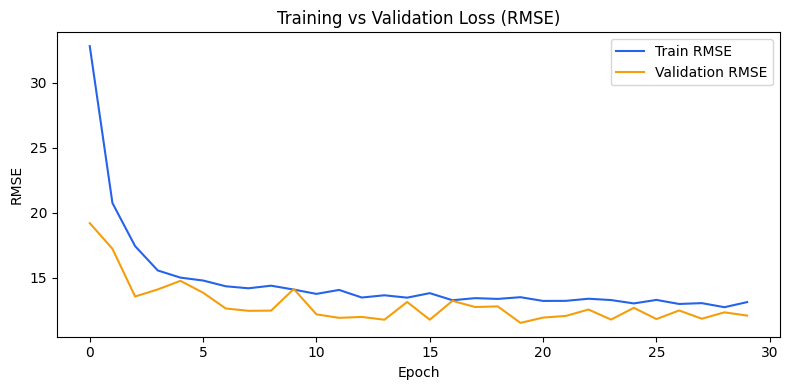

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(train_rmse_history, label="Train RMSE", color="#2563eb")
plt.plot(val_rmse_history, label="Validation RMSE", color="#f59e0b")
plt.title("Training vs Validation Loss (RMSE)")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / "training_loss_curve.png", dpi=150)
plt.show()

Validation RMSE: 11.6714
Prediction STD (should be > 0): 39.6281


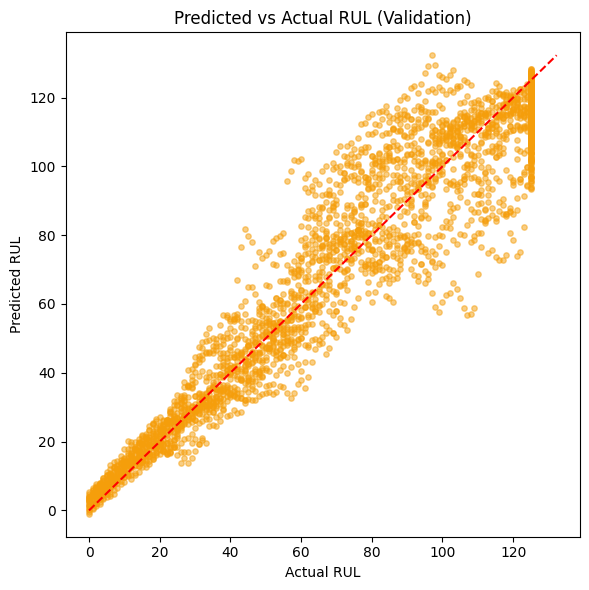

Saved checkpoint: /Users/manankapoor/Downloads/aiproj/model/best_model.pth


In [16]:
best_model = LSTMRULModel(input_size=14, hidden_size=128, num_layers=2, dropout=0.2).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_DIR / "best_model.pth", map_location=DEVICE))
best_model.eval()

with torch.no_grad():
    val_preds = best_model(torch.tensor(X_val, dtype=torch.float32, device=DEVICE)).cpu().numpy() * RUL_CAP

val_rmse = float(np.sqrt(mean_squared_error(y_val, val_preds)))
pred_std = float(np.std(val_preds))

print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Prediction STD (should be > 0): {pred_std:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_val, val_preds, alpha=0.5, s=15, color="#f59e0b")
lims = [0, max(float(y_val.max()), float(val_preds.max()))]
plt.plot(lims, lims, color="red", linestyle="--", linewidth=1.5)
plt.title("Predicted vs Actual RUL (Validation)")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.tight_layout()
plt.savefig(MODEL_DIR / "predicted_vs_actual_rul.png", dpi=150)
plt.show()

print("Saved checkpoint:", MODEL_DIR / "best_model.pth")